<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/projects/credit_scoring_project/credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv("/content/drive/MyDrive/AI learning/ai_project_2026/adult/adult11.csv")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'salary'],
      dtype='object')

In [4]:
df.shape

(48842, 15)

In [5]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [6]:
df.duplicated().sum()

np.int64(52)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   gender          48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  salary          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


- salary ustuni object turida ekan

In [8]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


- 90 yoshli mijozlar bank uchun outlier bo'lishi mumkin chunki bu yoshda odatda kredit olinmiydi
- capital-gain ustunidagi max qiymat 99999 ga teng , bu shubhali
- hours-per-week ustunidagi max qiymat ham oulier

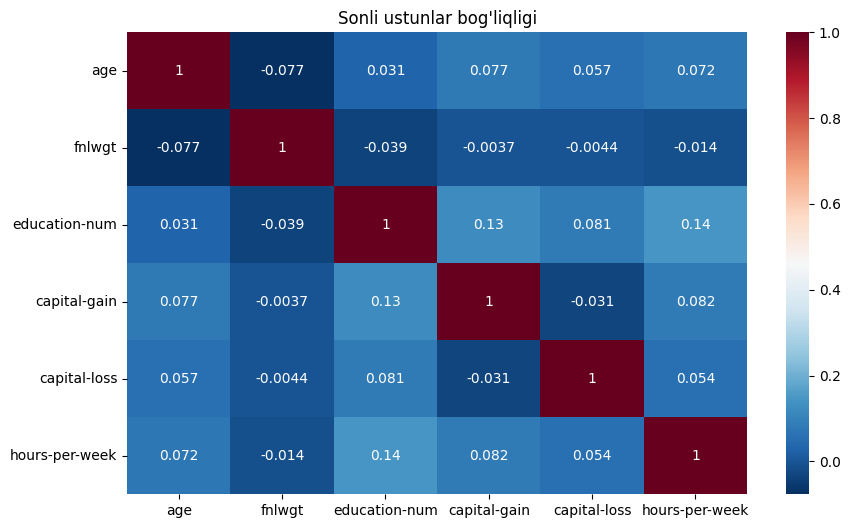

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.title("Sonli ustunlar bog'liqligi")
plt.show()

- issiqlik haritasidagi ko'rsatkichlarning deyarli barchasi 0 ga juda yaqin
- ranglarni deyarli barcha ko'k rangda bo'lgani - ustunlar orasida deyarli chiziqli bog'liqlik yo'qligini bildiradi

In [10]:
# ma'lumotlar ichida ? belgisi bor edi , shular nechtaligini aniqlash
for col in df.columns:
    if df[col].dtype == 'object':
        count = (df[col].str.strip() == '?').sum()
        if count > 0:
            print(f"{col}: {count} ta '?' bor")

workclass: 2799 ta '?' bor
occupation: 2809 ta '?' bor
native-country: 857 ta '?' bor


- agar insonning ish joyi turi noma'lum bo'lsa, katta ehtimol bilan uning kasbi ham noma'lum bo'ladi . Shuning uchun ham workclass va occupation ustunidagi "?" lar deyarli bir xil
- Bank sohasida mijozning kasbi va ish joyi turi uning kredit layoqatini baholashda eng muhim faktorlardan hisoblanadi. Shuning uchun bularni o'chirib tashlamiymiz

In [11]:
# matnli ustunlardagi unikal qiymatlarni aniqlash
print("Oilaviy ahvol ustunidagi unikal qiymatlari:", df['marital-status'].unique())

Oilaviy ahvol ustunidagi unikal qiymatlari: ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']


- bu kategoriyalarni keyinchalik 2 guruhga married va single qilishimiz mumkin

In [12]:
# odatda kasb egalari haftasiga 70 soat ishlaydi
# 70 soatdan ko'p ishlaydigan mijozlarni aniqlash
(df['hours-per-week']>70).sum()

np.int64(774)

- 774 ta mijoz haftasiga 70 soatdan ko'p ishlaydi . Bularning daromadi juda yuqori yoki moliyaviy barqarorligi past bo'lishi mumkin (bir nechta joyda ishledigan bo'lishi mumkin)

In [13]:
# bashorat qilmoqchi bo'lgan ustunimiz taqsimotini aniqlash
print(df['salary'].value_counts())

salary
<=50K    37155
>50K     11687
Name: count, dtype: int64


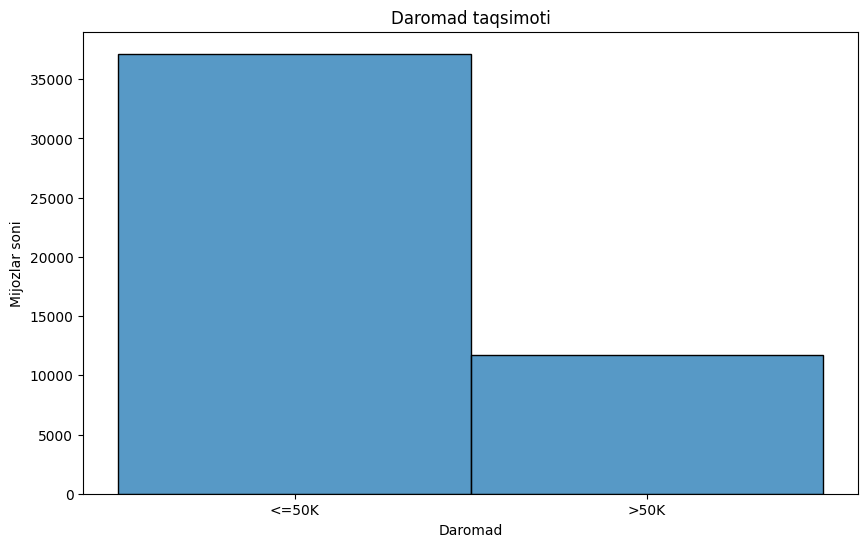

In [14]:
# grafikda tahlil qilamiz
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df['salary'])

plt.title("Daromad taqsimoti")
plt.xlabel("Daromad")
plt.ylabel("Mijozlar soni")
plt.show()

- yillik daromadi 50K dan kam yoki teng bo'lgan mijozlar soni 37000 dan ortiq
- yillik daromadi 50K dan ko'p bo'lgan mijozlar esa 11500-12000 atrofida
- 50K dan kam daromad qiluvchi mijozlar 50K ko'p daromad qiluvchi mijozlarga qaraganda qariyb 3 baravar ko'p

In [15]:
# foiz ko'rinishida
df['salary'].value_counts(normalize=True) * 100

,proportion
salary,
<=50K,76.071823
>50K,23.928177


- ushbu bashorat qilishimiz kerak bo'lgan ustunimizdagi ma'lumotlar teng emas , ya'ni balansda emas
- bu kelajakda modelimizni noto'g'ri bashorat qilishiga olib keladi . Daromadi kam degan javobga og'ib ketadi
- modelimiz og'ib ketmasligi uchun train test setga balansni saqlagan holda yani train setga ham 76/24 , test setga ham 76/24 balansini ushagan holda bo'lishimiz kerak

##Data spliting : train/test set

In [16]:
from sklearn.model_selection import train_test_split

# train va test setlarga bo'lish (80%-train, 20%-test)
# y-ustunidagi 76/24 nisbati saqlanib qolgan holda
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df['salary'])

print("train_set hajmi:", train_set.shape)
print("test_set hajmi:", test_set.shape)

train_set hajmi: (39073, 15)
test_set hajmi: (9769, 15)


## Data Cleaning . train_set

In [17]:
# yuqorida duplikatlarni aniqlagan edik
# duplikatlarni o'chirish
train_set = train_set.drop_duplicates()
train_set.shape

(39040, 15)

In [18]:
# yuqori "?" belgisi bor ekanligini ko'rgandik , shular nechtaligini aniqlash
miss_val_train = (train_set == '?').sum()
miss_val_train[miss_val_train > 0]

,0
workclass,2220
occupation,2230
native-country,681


- keyinchalik Pipelinelar bilan ishlashimiz uchun "?" belgilarni NaN qilishimiz kerak

In [19]:
# "?" larni NaN ga almashtirish
train_set = train_set.replace("?", np.nan)

# NaN lar sonini aniqlash
train_set.isnull().sum()[train_set.isnull().sum()>0]

,0
workclass,2220
occupation,2230
native-country,681


- agar inson hech qayerda ishlamasa , uning haftalik ish soati ham 0 ga teng bo'lishi kerak yoki juda kam bo'lishi kerak . Workclass ustunidagi NaN bo'lganlarni o'rtacha necha soat ishlashini aniqlash orqali ma'lumotlar xatolik bilan tushganmi yoki biror sabab borligini aniqlemiz

In [20]:
# workclassdagi NaN qiymatli ma'lumotlardan haftalik ishlash soatlarini tahlil qilamiz
miss_trainset = train_set[train_set['workclass'].isna()]

miss_trainset['hours-per-week'].describe()

,hours-per-week
count,2220.000000
mean,31.769820
std,15.239464
min,1.000000
25%,20.000000
50%,36.000000
75%,40.000000
max,99.000000


- ish joyi va kasbi yozilmay qolgan odamlar haftasiga o'rtacha 31.7 soat ishlashadi . Ular ishsiz emas

In [21]:
miss_trainset['age'].describe()

,age
count,2220.000000
mean,40.267117
std,20.256519
min,17.000000
25%,21.000000
50%,34.000000
75%,61.000000
max,90.000000


- kasbi yozilmagan mijozlarni o'rtachasi 40 yosh , bu guruhda o'smirlar ham qariyalar ham bor

In [22]:
miss_trainset['salary'].describe()

,salary
count,2220
unique,2
top,<=50K
freq,2005


- ma'lumotlari yozilmagan insonlar - asosan quyi/o'rta daromadli insonlar ekanini aniqlashimiz mumkin
- agarda ularni moda (eng ko'p takrorlangan qiymatlar) bilan to'ldirsak modelimiz og'ib ketadi . **Shuning uchun kasbi va ish joyi ko'rsatilmaganlarni keyinchalik Pipelineda "Unknown" guruhiga olamiz**
- shu bilan birga oilaviy holatini ham 0 va 1 dan iborat guruhlarga bo'lib bitta ustun qivoramiz

In [23]:
# test_setdagi "?" larni ham NaN qilib ketamiz
test_set = test_set.replace("?", np.nan)
test_set.isnull().sum()

,0
age,0
workclass,575
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,575
relationship,0
race,0
gender,0


In [24]:
from sklearn.compose import ColumnTransformer # matnli pipeline yaratadi
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # NaN larni to'ldiradi
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# features va labellarni ajratish
X_train = train_set.drop('salary', axis=1)
y_train = train_set['salary']

X_test = test_set.drop('salary', axis=1)
y_test = test_set['salary']

- marital-status (oilaviy holati) ustunini ikki guruhga 1-oilali va 0-oilasi yo'q , ya'ni turmush qurgan va qurmagan qilib guruhlemiz . Bu kelajakda OneHotEncoder qiganimizda ortiqcha ustunlar yaratmaslikni oldini oladi
- shu bilan birga `capital-gain` daromad va `capital-loss` larni birini ikkinchisidan ayirish orqali mijozning sof foydasi (balansi) ni aniqlemiz va yangi ustun yaratmiz
- native-country ustunidagi davlatlarni 3 guruhga : United-States, Unknown va Ohter ga ajratamiz , chunki ma'lumotlarimizni 89% United_states , kiritilmagan ma'lumotlar Unknown qolgan kam qiymatli davlatlar Other bo'ladi

In [25]:
# yuqoridagi amallarni bajarish uchun funksiya yozamiz
def add_custom_features(X):
    X_copy = X.copy()

    # is_married ustunini yaratish
    married_statuses = ['Married-civ-spouse', 'Married-AF-spouse', 'Married-spouse-absent']
    X_copy['is_married'] = X_copy['marital-status'].apply(lambda x: 1 if x in married_statuses else 0)

    # net_capital ustunini yaratish
    X_copy['net_capital'] = X_copy['capital-gain'] - X_copy['capital-loss']

    # native-country ustunini 3 guruhga ajratish
    def group_country(country):
        if country == 'United-States':
            return 'United-States'
        elif country in ['Unknown', '?'] or pd.isna(country):
            return 'Unknown'
        else:
            return 'Other'

    X_copy['native-country'] = X_copy['native-country'].apply(group_country)

    return X_copy

In [26]:
# X-train va X_testlarga yangi ustunlar qo'shish
X_train_fe = add_custom_features(X_train)
X_test_fe = add_custom_features(X_test)

# sonli va matnli ustunlar nomlarini list qilib olish - pipelinega berish uchun
cat_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
num_cols = X_train_fe.drop(columns=cat_cols).columns.tolist()

- education ustunini omadik , sababi uni son bilan ifodalovchi educational-num ustuni mavjud

In [27]:
num_cols

['age',
 'fnlwgt',
 'education',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'is_married',
 'net_capital']

In [28]:
# num_colsga education ustuni tushib qolgan , uni drop qilish
num_cols.remove('education')

In [29]:
# Pipelinelar qurish
from sklearn.pipeline import Pipeline

# matnli ustunlardagi NaN larni to'ldirish uchun SimpleImputer
from sklearn.impute import SimpleImputer

# matnlarni sonlarga o'tkizish - OneHotEncoder , normalizatsiya qilish uchun - StandartScaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# pipelinelarni ustunlarga bog'lash uchun
from sklearn.compose import ColumnTransformer

# sonli ustunlar uchun pipeline yaratish
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# matnli ustunlar uchun pipeline yaratish
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# pipelinelarni ustunlarga bog'lash
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [30]:
# X_train ma'lumotlarini pipelinedan o'tkizish
X_train_prepared = full_pipeline.fit_transform(X_train_fe)

# X_test ma'lumotlarini transform qilish
X_test_prepared = full_pipeline.transform(X_test_fe)

print("Ma'lumotlar ML uchun tayyor...")
print("X_train shape:", X_train_prepared.shape)
print("X_test shape:", X_test_prepared.shape)

Ma'lumotlar ML uchun tayyor...
X_train shape: (39040, 55)
X_test shape: (9769, 55)


##Model training / Logistic Regression

- birinchi LogisticRegression modelini quramiz . Hisoblash tezligi o'ta yuqori va qaysi ustun qarorga qancha ta'sir qilayotganini ko'rish juda oson ko'ramiz
- keyin Random Forest modelini quramiz . U ustunlar o'rtasidagi murakkab va nochiziqli bog'liqliklarni ham oson aniqledi

In [31]:
# Logistic Regression modelini qurish
from sklearn.linear_model import LogisticRegression

# natijalarni baholash uchun
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# model yaratish va o'qitish
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_prepared, y_train)

# bashorat qilish
y_pred = log_model.predict(X_test_prepared)

# natijalarni baholash
print("Accuracy (aniqlik):", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy (aniqlik): 0.853618589415498
Classification report:
               precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.60      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.78      9769
weighted avg       0.85      0.85      0.85      9769



- Logistic Regression modeli kam va o'rta daromadli insonlarni yaxshi taniyapti , lekin yuqori daromadli insonlarni aksarini aniqlay olmayapti
- 50K dan kam topadigan insonlarni 93% tori aniqladi , lekin 50K dan yuqori topadigan insonlarni 60% ini tori aniqladi qolgan 40% 50K dan kam topadi deb o'ylayapti
- 50K dan yuqori topadigan insonlarni aniqlashi past bo'ldi
- ushbu model Bank Kredit Riskini Baholash uchun ishlatiladi, biz Precision (74%) ko'rsatkichiga e'tibor qaratamiz, chunki noto'g'ri daromad ko'rsatilgan mijozga kredit berish bankka xavf tug'diradi
- endi esa murakkab modellar qurishga o'tamiz

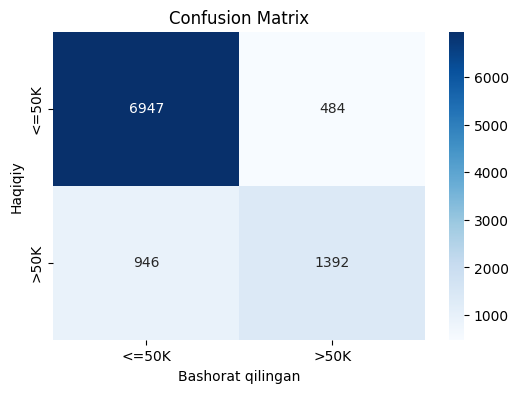

In [36]:
# Logistic Regressor uchun grafik chizish
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.xlabel('Bashorat qilingan')
plt.ylabel('Haqiqiy')
plt.title('Confusion Matrix')
plt.show()

-

## Random Forest Classifier

In [32]:
from sklearn.ensemble import RandomForestClassifier

# model yaratish
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=12)

# modelni o'qitish
rf_model.fit(X_train_prepared, y_train)

# bashorat qilish
y_pred_rf = rf_model.predict(X_test_prepared)

In [33]:
# natijalar
print("Accuracy (aniqlik):", accuracy_score(y_test, y_pred_rf))
print("Classification report:\n", classification_report(y_test, y_pred_rf))

Accuracy (aniqlik): 0.8659023441498618
Classification report:
               precision    recall  f1-score   support

       <=50K       0.88      0.96      0.92      7431
        >50K       0.82      0.57      0.67      2338

    accuracy                           0.87      9769
   macro avg       0.85      0.76      0.79      9769
weighted avg       0.86      0.87      0.86      9769



- RandomForestClassifier modeli 50K ga teng yoki undan kam daromad qiladigan odamlarni 96% ini aniqlay oldi . Bu judayam yaxshi
- Lekin bu model ham 50K dan yuqori daromad qiladigan insonlarni unchalik yaxshi topa olmayapti , 57% ini aniqlayapti qolgan 43% ini o'tkizib yubormoqda
- Buning sababi esa ma'lumotlarimiz balansda emasligi . Ma'lumotlarimizni ko'p qismi 50K ga teng va undan kam daromad qiladigan insonlarni ma'lumoti , kam qismi esa 50K dan yuqori daromad qiladi

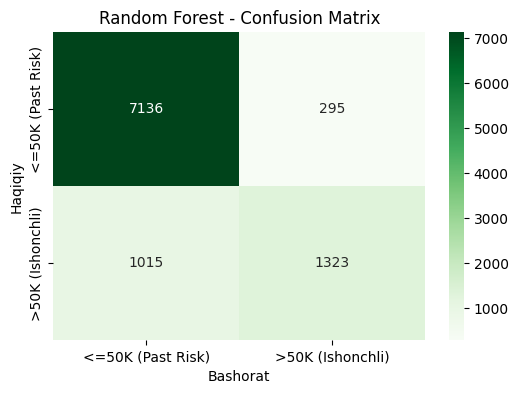

In [35]:
# RFC modeli uchun Confusion Matrix visualizatsiyasi
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['<=50K (Past Risk)', '>50K (Ishonchli)'],
            yticklabels=['<=50K (Past Risk)', '>50K (Ishonchli)'])

plt.xlabel('Bashorat')
plt.ylabel('Haqiqiy')
plt.title('Random Forest - Confusion Matrix')
plt.show()

- Modelimiz 7136 ta 50K ga teng yoki undan past daromad qiluvchilarni to'g'ri aniqlagan . Huddi shunga o'xshab 1323 ta 50K dan yuqori daromad qiladiganlar ham to'g'ri aniqlagan
- Katta xatolar FN da , aslida 50K dan ko'p daromad qiluvchi insonlarni modelimiz 50K ga teng yoki undan kam daromad qiluvchi deya bashorat qilgan . Huddi shunga o'xshab 50K ga teng yoki undan kam daromad qiluvchilarni 50K dan yuqori daromad qiladi deya xato bashorat qilgan